# Sea-surface height and red tides

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/aselshall/eds/HEAD)

---

In [1]:
import os
import copernicusmarine
import shutil


import xarray as xr
import numpy as np
import pandas as pd
import math
from scipy.io import loadmat  # this is the SciPy module that loads mat-files

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import warnings
#  Suppress warnings issued by Cartopy when downloading data files
warnings.filterwarnings('ignore')

Going With the Flow: Visualizing Ocean Currents with ECCO   
https://science.nasa.gov/earth/oceans/going-with-the-flow-visualizing-ocean-currents-with-ecco/

https://link.springer.com/article/10.1038/s43247-025-02108-4 

For publishing do HBMA with zos average, delta, and track 26


---

## 1. Problem Statement

The hypothesis is that high sea-level anomalies in the Gulf of Mexico is a  a necessary condition for the occurance of red tides (high concentration of K. brevis cell counts) in the West Florida shielf. High sea-level anomalies is asscoiated with the Gulf Loop Current, which is a warm ocean current that flows from the Caribbean to the Gulf of Mexico, then loops east and south along the Florida coast, and exits through the Straits of Florida. To investigate the relationship between sea level anomalies (SLA) and red tide occurrences (K. brevis cell counts), we you can employ several statistical methods such as time series analysis, regression analysis, event study analysis, spatial correlation analysis and machine learning models. The objective of this exercise is to prepare data for analysis. Specifically, our tasks are to:
- download and reduce monthly 3d (x,y, time) SLA data to monthly 2d (x, time) data
- download and reduce daily 3d (x,y, time) K. brevis data to weekly 1d (time) data
- Redue monthly 2D (x, time) sla data into to weekly 1d (time) data with temporal alignment with K. brevis data
- transform weekly 1d SLA and K. brevs data with techniques for stationarity, detrending, zero mean, normalization, etc.

This is all needed so the we you can directly compare SLA data with K. brevis cell count data and perform statstical analysis.

## 2. Exploring SLA data

### 2.1 Download global data (*optional*)

From [Climate Data Store (CDS)](https://cds.climate.copernicus.eu/#!/home) you can download the [Sea level gridded data from satellite observations for the global ocean from 1993 to present](
https://cds.climate.copernicus.eu/cdsapp#!/dataset/satellite-sea-level-globa). You can manually download the data from CDS website or through API. This [link](
https://cds.climate.copernicus.eu/api-how-to#install-the-cds-api-ke) contains information on how to use the CDS API and API key. Additional information can be found in this [link](https://confluence.ecmwf.int/display/CKB/How+to+install+and+use+CDS+API+on+Windows).

To run the code below, you need first to set the CDS API key.

https://data.marine.copernicus.eu/products 

https://data.marine.copernicus.eu/product/GLOBAL_MULTIYEAR_PHY_001_030/description

In [2]:
# Duration configuration (Month, Day)
select_duration=1
duration = ['M', 'D']
zos_folder = f"raw_data/zos_{duration[select_duration]}"

In [3]:
#Download data if does not exit
download_data= False
if download_data:
    # Configuration for both time periods and datasets
    configs = [
        {
            'start_datetime': "1993-01-01T00:00:00",
            'end_datetime': "2021-06-01T00:00:00",
            'dataset_id': f"cmems_mod_glo_phy_my_0.083deg_P1{duration[select_duration]}-m"
        },
        {
            'start_datetime': "2021-07-01T00:00:00",
            'end_datetime': "2025-02-01T00:00:00",
            'dataset_id': f"cmems_mod_glo_phy_myint_0.083deg_P1{duration[select_duration]}-m"
        }
    ]
    
    # Ensure 'zos' folder exists
    if not os.path.exists(zos_folder):
        os.makedirs(zos_folder)
    
    # Loop through both configurations and download data
    for config in configs:
        print(f"Downloading data from {config['start_datetime']} to {config['end_datetime']}...")
        
        output = copernicusmarine.subset(
            dataset_id=config['dataset_id'],
            dataset_version="202311",
            variables=["zos"],
            minimum_longitude=-100,
            maximum_longitude=-75,
            minimum_latitude=18,
            maximum_latitude=32,
            start_datetime=config['start_datetime'],
            end_datetime=config['end_datetime'],
            minimum_depth=0.49402499198913574,
            maximum_depth=0.49402499198913574,
            coordinates_selection_method="strict-inside",
            disable_progress_bar=False,
            username="aelshall",
            password="@lhmedAllah11"
        )
    
        # Extract file path from the ResponseSubset object
        output_file = output.file_path if hasattr(output, 'file_path') else None
        
        # Move file to zos folder if it exists
        if output_file:
            destination = os.path.join(zos_folder, os.path.basename(output_file))
            shutil.move(output_file, destination)
            print(f"File moved to {destination}")
        else:
            print(f"No file downloaded for {config['start_datetime']} to {config['end_datetime']}. Check dataset settings.")
    
    print("All downloads complete.")


### 2.2 Select and save Gulf of Mexico data (*optional*)

We need to extract the Gulf of Mexico data from this global dataset as follows.

In [4]:
# Read all files
ds = xr.open_mfdataset(f"{zos_folder}/*.nc", combine="by_coords")  # , parallel=True

In [5]:
# Display dataset
ds

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 11716, latitude: 169, longitude: 301)
Coordinates:
  * latitude   (latitude) float32 676B 18.0 18.08 18.17 ... 31.83 31.92 32.0
  * longitude  (longitude) float32 1kB -100.0 -99.92 -99.83 ... -75.08 -75.0
  * time       (time) datetime64[ns] 94kB 1993-01-01 1993-01-02 ... 2025-01-28
Data variables:
    zos        (time, latitude, longitude) float32 2GB dask.array<chunksize=(10408, 169, 301), meta=np.ndarray>
Attributes:
    title:                     daily mean fields from Global Ocean Physics An...
    comment:                   CMEMS product
    Conventions:               CF-1.4
    source:                    MERCATOR GLORYS12V1
    institution:               MERCATOR OCEAN
    history:                   2023/06/01 16:20:05 MERCATOR OCEAN Netcdf crea...
    references:                http://www.mercator-ocean.fr
    copernicusmarine_version:  2.0.1

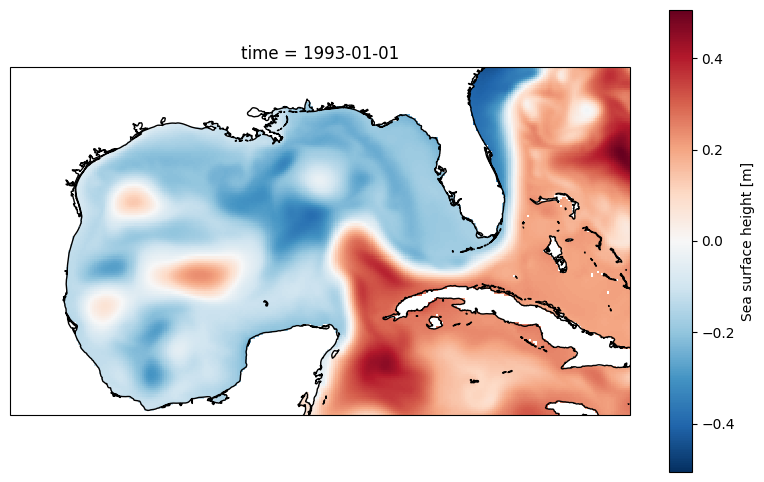

In [6]:
# Display 2d data  at the first time step
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ds.zos[0,:,:].plot()
ax.coastlines();

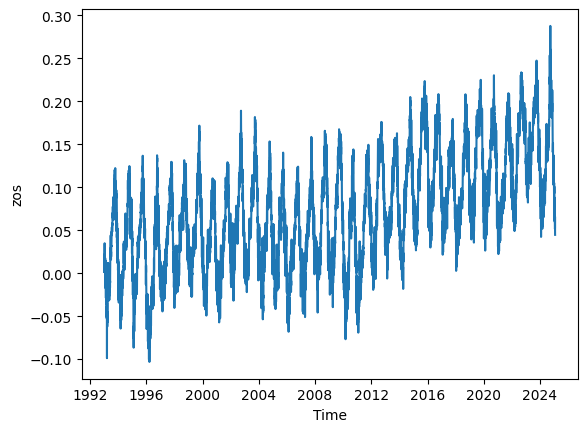

In [7]:
# Calculate the mean SLA across the 'latitude' and 'longitude' dimensions
mean_sla = ds.zos.mean(dim=('latitude', 'longitude')).plot()

In [8]:
#Let us learn more about SLA
ds.zos.attrs

{'long_name': 'Sea surface height',
 'valid_min': -6228,
 'units': 'm',
 'valid_max': 5684,
 'unit_long': 'Meters',
 'standard_name': 'sea_surface_height_above_geoid'}

In [9]:
#[1] Load zos data 
member='AVISO-1-1_phy-001-030_r0'

#[2] Load Bathymetry_AVISO data
#Bathymetry=['NOAA','B-50','B-300','B-1000','B-2000','B-3000']
Bathymetry=['B300']
for bathymetry in Bathymetry: 
    yx=np.loadtxt('input/DigitizeSegments_Bathymetry_AVISO_{}.csv'.format(bathymetry),delimiter=',')
    print(yx.shape)
    
# Create coordinates for the four labels
time = ds.time
latitudes= yx[:,0]  # latitude values 
longitudes= yx[:,1]  # longitude values 

(119, 2)


In [10]:
# Create a 2D meshgrid of lat/lon pairs
lat_broadcasted = xr.DataArray(latitudes, dims=("points",))
lon_broadcasted = xr.DataArray(longitudes, dims=("points",))

# Perform interpolation for all points at once using broadcasting
interpolated = ds['zos'].interp(latitude=lat_broadcasted, longitude=lon_broadcasted)

# Convert to a pandas DataFrame
df_zos = interpolated.to_pandas()

# Rename columns to match lat/lon pairs for clarity
df_zos.columns = [f"lat_{lat:.2f}_lon_{lon:.2f}" for lat, lon in zip(latitudes, longitudes)]

# Display the DataFrame shape to confirm dimensions
print(df_zos.shape)  # Should be (11716, 119)
df_zos.head()

(11716, 119)


,lat_28.67_lon_-86.00,lat_28.58_lon_-85.92,lat_28.50_lon_-85.83,lat_28.42_lon_-85.75,lat_28.42_lon_-85.67,lat_28.33_lon_-85.67,lat_28.33_lon_-85.58,lat_28.33_lon_-85.50,lat_28.25_lon_-85.50,lat_28.25_lon_-85.42,...,lat_24.58_lon_-80.50,lat_24.67_lon_-80.42,lat_24.67_lon_-80.33,lat_24.75_lon_-80.25,lat_24.83_lon_-80.25,lat_24.92_lon_-80.17,lat_25.00_lon_-80.08,lat_25.08_lon_-80.08,lat_25.17_lon_-80.00,lat_25.25_lon_-80.00
time,,,,,,,,,,,,,,,,,,,,,
1993-01-01,-0.210578,-0.214545,-0.218818,-0.217902,-0.221564,-0.213630,-0.216681,-0.220954,-0.213019,-0.216987,...,-0.066836,-0.081484,-0.055849,-0.064394,-0.096133,-0.090640,-0.079958,-0.111698,-0.087893,-0.108036
1993-01-02,-0.217597,-0.220344,-0.224006,-0.223701,-0.228278,-0.219428,-0.223701,-0.228889,-0.219733,-0.224616,...,-0.066836,-0.080874,-0.057070,-0.064699,-0.094913,-0.091250,-0.082705,-0.113834,-0.089114,-0.108951
1993-01-03,-0.202338,-0.204169,-0.206305,-0.206000,-0.211188,-0.202948,-0.207831,-0.213630,-0.203864,-0.209052,...,-0.055849,-0.065310,-0.041810,-0.047304,-0.074770,-0.072024,-0.065920,-0.093692,-0.069582,-0.088198
1993-01-04,-0.217597,-0.218513,-0.218207,-0.217292,-0.222480,-0.215461,-0.220344,-0.226142,-0.217292,-0.222175,...,-0.096133,-0.101932,-0.077517,-0.080264,-0.104678,-0.099490,-0.090945,-0.115665,-0.090335,-0.108646
1993-01-05,-0.208441,-0.208441,-0.206915,-0.206000,-0.211188,-0.205390,-0.211188,-0.218207,-0.209052,-0.214545,...,-0.124821,-0.124821,-0.096438,-0.099185,-0.126041,-0.120243,-0.109561,-0.133061,-0.107120,-0.124516


In [11]:
# Save DataFrame to file
df_zos.to_csv("output/zos_interpolated.csv", index=True)

# Save lat/lon to separate file
lat_lon = pd.DataFrame({
    "latitude": latitudes,
    "longitude": longitudes
})
lat_lon.to_csv("lat_lon.csv", index=False)


In [12]:
##### [1] Display processed results
#Section information (KB_Data_ESM)
#m=loadmat('zos_data_B300/Optimization/R3210.mat')
m=loadmat('input/zos_data_B300_segments.mat')

ndata = {n: m['row'][n][0,0] for n in m['row'].dtype.names}
dfm=pd.DataFrame.from_dict(dict((column, ndata[column][0]) for column in [n for n, v in ndata.items() if v.size == 1]))
#display(dfm)

#display(dfm)
NSeg=dfm['N'][0]; ns=dfm['Nstr'][0]; ne=dfm['Nend'][0];SSeg=dfm['S'][0]; ss=dfm['Sstr'][0]; se=dfm['Send'][0];
print('{} ({},{}) and {} ({},{}) north and south segments with {} and {} cells, respectively'.format(NSeg,ns,ne,SSeg,ss,se,ne-ns+1,se-ss+1))


B-300 (9,22) and B-300 (59,78) north and south segments with 14 and 20 cells, respectively


## 3. Red tide data

In [13]:
# Read a csv file with Pandas
df = pd.read_csv('input/habsos_20240430.csv', low_memory=False)

# Select column names that you need for your analysis (e.g., 'LATITUDE', 'LONGITUDE', 'SAMPLE_DATE', 'CELLCOUNT', etc.) 
selected_columns = ['STATE_ID','DESCRIPTION','LATITUDE', 'LONGITUDE', 'SAMPLE_DATE', 'CELLCOUNT',
                   'SALINITY','WATER_TEMP','WIND_DIR','WIND_SPEED']

# Filter the DataFrame to include only the selected columns
df = df[selected_columns]

# Display your DataFrame
df

# Create a new column 'region' with default value 'Other'
df['REGION'] = 'Other'

# Mask for dicing: Define mask for Tampa Bay region based on latitude and longitude values
tampa_bay_mask = (df['LATITUDE'] >= 27) & (df['LATITUDE'] <= 28) & (df['LONGITUDE'] >= -85)

# Assign value 'Tampa Bay' to rows matching Tampa Bay mask 
df.loc[tampa_bay_mask, 'REGION'] = 'Tampa Bay'

# Mask for decing: Define mask for Charlotte Harbor estuary region  based on latitude and longitude values
charlotte_harbor_mask = (df['LATITUDE'] >= 25.5) & (df['LATITUDE'] < 27) & (df['LONGITUDE'] >= -85)

# Assign value 'Charlotte Harbor' to rows matching Charlotte Harbor mask
df.loc[charlotte_harbor_mask, 'REGION'] = 'Charlotte Harbor'

#Display dataframe
df

,STATE_ID,DESCRIPTION,LATITUDE,LONGITUDE,SAMPLE_DATE,CELLCOUNT,SALINITY,WATER_TEMP,WIND_DIR,WIND_SPEED,REGION
0,TX,Copano Bay 4,28.07237,-97.21968,2023/09/27,0,NaN,NaN,NaN,NaN,Other
1,TX,Copano Bay 2,27.99567,-97.16831,2023/09/27,0,NaN,NaN,NaN,NaN,Other
2,TX,Copano Bay 3,28.03930,-97.15836,2023/09/27,0,NaN,NaN,NaN,NaN,Other
3,TX,Copano Bay 1,28.06491,-97.11270,2023/09/27,0,NaN,NaN,NaN,NaN,Other
4,FL,off New Smyrna Beach; Atlantic,29.17460,-78.27890,1990/12/20,0,NaN,24.2,NaN,NaN,Other
...,...,...,...,...,...,...,...,...,...,...,...
211829,TX,"Nueces Bay, East of Nueces River Delta",27.86611,-97.51636,2015/10/14,0,NaN,NaN,NaN,NaN,Other
211830,TX,Viola Turning Basin (Sample ID 1230-1),27.84455,-97.52228,2009/12/30,1000000,NaN,NaN,NaN,NaN,Other
211831,TX,"South Padre Island, Brazos Santiago Pass south...",26.18451,-97.66535,2015/09/25,922000,34.0,29.0,NaN,NaN,Other
211832,TX,"South Padre Island, Brazos Santiago Pass south...",26.18451,-97.66535,2015/10/02,1513000,NaN,NaN,NaN,NaN,Other


In [14]:
# Function to convert DMS to decimal degrees
def dms_to_decimal(degrees, minutes, seconds, direction):
    decimal = degrees + minutes / 60 + seconds / 3600
    if direction in ['S', 'W']:
        decimal = -decimal
    return decimal

# Input values
lat_dms = (25, 42, 1, 'N')
lon_dms = (83, 38, 28, 'W')

# Convert to decimal degrees
lat_decimal = dms_to_decimal(*lat_dms)
lon_decimal = dms_to_decimal(*lon_dms)

print(f"Latitude: {lat_decimal:.6f}, Longitude: {lon_decimal:.6f}")

Latitude: 25.700278, Longitude: -83.641111


## 4. Plot red tide and zos data

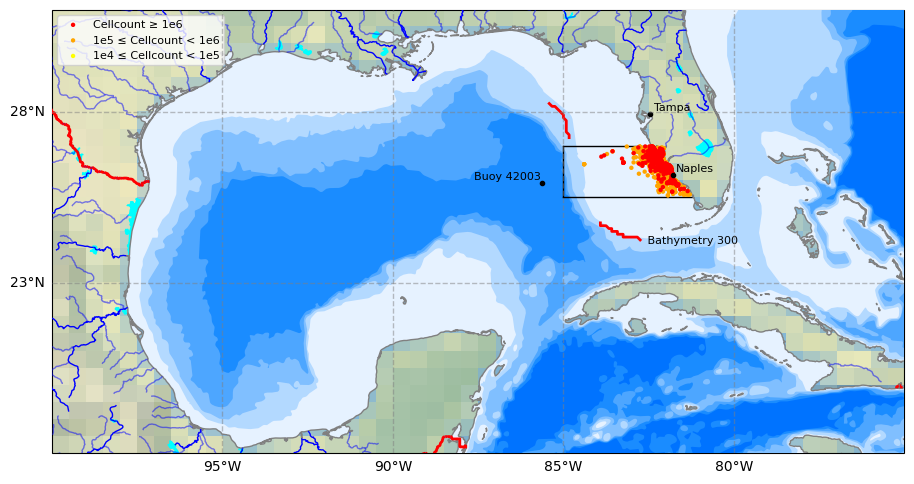

In [15]:
# 0) Select data to plot
Plot_Num= 2  #Type 1 to plot SLA data for the first time step or 2 to plot bathymetry lines

# 1) Select plot extend: Lon_West, Lon_East, Lat_South, Lat_North in Degrees
extent = [-75, -100, 18, 31] #Gulf of Mexico
#extent = [-80, -100, 20, 31] 

# 2) Select projection
projPC = ccrs.PlateCarree()

# 3) Create figure
fig = plt.figure(figsize=(11, 8.5))
#plt.subplots_adjust(hspace=0.1, wspace=0.2)  # Adjust the height and width spaces between subplots

# 4) Loop to plot variables 
variable = 'sla'
colormap = 'coolwarm'
title=''

# 5) Create Axes     
ax = plt.subplot(1, 1, 1, projection=projPC)

# 6) Setting the extent of the plot
ax.set_extent(extent, crs=projPC)

# 7) Add plot title 
ax.set_title(title, fontsize=10, loc='left')

# 8) Add gridlines (we need to cutomize grid lines to improve visualization)                              
gl = ax.gridlines(draw_labels=True, xlocs=np.arange(extent[1],extent[0], 5), ylocs= np.arange(extent[2], extent[3], 5),
                  linewidth=1, color='gray', alpha=0.5, linestyle='--',  zorder=40)

gl.right_labels = False  # 
gl.top_labels = False    # Set the font size for x-axis labels
gl.xlabel_style = {'size': 10}  # Set the font size for x-axis labels
gl.ylabel_style = {'size': 10}  # Set the font size for y-axis labels

# 9) Adding Natural Earth features
## Pre-defined features
ax.set_facecolor(cfeature.COLORS['water'])  #Blackgroundwater color for the ocean
#ax.add_feature(cfeature.LAND.with_scale('10m'), zorder=20) 
ax.add_feature(cfeature.LAKES.with_scale('10m'), color='aqua', zorder=21) 
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), color='gray', zorder=21) 
ax.add_feature(cfeature.BORDERS, edgecolor='red',facecolor='none', linewidth=2, zorder=22) 
ax.stock_img()

## General features (not pre-defined)
ax.add_feature(cfeature.NaturalEarthFeature(
    'physical', 'rivers_lake_centerlines', scale='10m', edgecolor='blue', facecolor='none') ,zorder=21)
ax.add_feature(cfeature.NaturalEarthFeature(
    'physical','rivers_north_america', scale='10m', edgecolor='blue', facecolor='none', alpha=0.5),zorder=21)

# 10) Adding user-defined features 
# Plot site area on GeoAxes given lon and lat coordinates in first subplot 
#ax.plot([-85.0, -85.0], [27, 28.0], color='black', linewidth=1, zorder = 15)    #Tampa Bay region
ax.plot([-85.0, -85.0], [25.5, 27.0], color='black', linewidth=1, zorder = 15)  # Charlotte Harbor est uary region 
#ax.plot([-85.0, -82.85], [28.0, 28.0], color='black', linewidth=1, zorder = 15)
ax.plot([-85.0, -82.4], [27, 27], color='black', linewidth=1, zorder = 15)
ax.plot([-85.0, -81.2], [25.5, 25.5], color='black', linewidth=1, zorder = 15)


## 11) Plot Track 026 line on GeoAxex and annotate with text using axes cooridnates in second subplot
#points = np.array([[-85.7940, 28.4487], [-83.6190, 23.8411]]) 
#ax.plot(longitudes, latitudes, color='black', linewidth=2, zorder = 15)
ax.plot(longitudes[ns:ne], latitudes[ns:ne], color='red', linewidth=2, zorder = 15)
ax.plot(longitudes[ss:se], latitudes[ss:se], color='red', linewidth=2, zorder = 15)
ax.text(0.75, 0.48, ' Bathymetry 300', transform=ax.transAxes,   #x,y 
        color='black', fontsize=8,  ha='center',  va='center',  rotation=0, zorder = 15)

## Adding names and locations of major cities
locations_coordinates = {"Tampa": [27.9506, -82.4572], 
                     #"Sarasota": [27.3364, -82.5307], 
                     #"Fort Myers": [26.6406, -81.8723], 
                     "Naples": [26.142, -81.7948],  
                        }
for location, coordinates in locations_coordinates.items():
    ax.plot(coordinates[1], coordinates[0],  
            transform=ccrs.PlateCarree(),  marker='o', color='black', markersize=3, zorder = 28)
    ax.text(coordinates[1] + 0.1, coordinates[0] + 0.1, 
            location, transform=ccrs.PlateCarree(), color='black', fontsize=8, zorder = 28)

locations_coordinates = {
                     "Buoy 42003": [25.9253, -85.6161],
                    #"Buoy 42097": [25.700278, -83.641111]
                        }
for location, coordinates in locations_coordinates.items():
    ax.plot(coordinates[1], coordinates[0],  
            transform=ccrs.PlateCarree(),  marker='o', color='black', markersize=3, zorder = 22)
    ax.text(coordinates[1] - 2, coordinates[0] + 0.1, 
            location, transform=ccrs.PlateCarree(), color='black', fontsize=8, zorder = 22)


# 11) Adding raster data and colorbar for the first three subplots
if Plot_Num ==1:
    # dataplot = ax.contourf(da.latitude, da.longitude, da.sla[0,:,:], 
    #                        cmap=colormap, zorder=12, transform=ccrs.PlateCarree())
    dataplot = ax.contourf(ds.longitude, ds.latitude, ds.sla[0,:,:], 
                           cmap=colormap, zorder=12, transform=ccrs.PlateCarree())
    colorbar = plt.colorbar(dataplot, orientation='horizontal', pad=0.1, shrink=1)  
    colorbar.set_label(ds.sla.attrs['standard_name'], fontsize=10)

#12) Plot 6 bathymetry lines using a loop
if Plot_Num == 2:
    # Names of bathymetry line 
    bathymetry_names = ['bathymetry_L_0', 'bathymetry_K_200', 
                        'bathymetry_J_1000', 'bathymetry_I_2000', 
                        'bathymetry_H_3000', 'bathymetry_G_4000'] 
    
    # Very light blue to light blue generated by ChatGPT 3.5 Turbo
    colors = [(0.9, 0.95, 1), (0.7, 0.85, 1), 
              (0.5, 0.75, 1), (0.3, 0.65, 1), 
              (0.1, 0.55, 1), (0, 0.45, 1), ]  
    
    # Loop to plot each bathymetry line
    for bathymetry_name, color in zip(bathymetry_names, colors):
        ax.add_feature(
            cfeature.NaturalEarthFeature(
                category='physical', 
                name=bathymetry_name, 
                scale='10m', 
                edgecolor='none', 
                facecolor=color), 
            zorder = 11)


# Plot red dots for CELLCOUNT >= 1e6 in the 'Charlotte Harbor' region with SAMPLE_DATE >= 1992-01-01
charlotte_harbor = df[
    (df['CELLCOUNT'] >= 1e5) & 
    (df['REGION'] == 'Charlotte Harbor') & 
    (df['LONGITUDE'] <= -81) & 
    (pd.to_datetime(df['SAMPLE_DATE']) >= pd.to_datetime('1992-01-01'))
]

# Plot red dots for CELLCOUNT >= 1e6
high = charlotte_harbor[charlotte_harbor['CELLCOUNT'] >= 1e6]
sc_high = ax.scatter(high['LONGITUDE'], high['LATITUDE'], 
                     color='red', s=10, edgecolor='none',
                     transform=ccrs.PlateCarree(), zorder=25)

# Plot orange dots for 1e5 <= CELLCOUNT < 1e6
medium = charlotte_harbor[(charlotte_harbor['CELLCOUNT'] >= 1e5) & (charlotte_harbor['CELLCOUNT'] < 1e6)]
sc_medium = ax.scatter(medium['LONGITUDE'], medium['LATITUDE'], 
                       color='orange', s=10, edgecolor='none',
                       transform=ccrs.PlateCarree(), zorder=24)

# Plot yellow dots for 1e4 <= CELLCOUNT < 1e5
low = charlotte_harbor[(charlotte_harbor['CELLCOUNT'] >= 1e4) & (charlotte_harbor['CELLCOUNT'] < 1e5)]
sc_low = ax.scatter(low['LONGITUDE'], low['LATITUDE'], 
                    color='yellow', s=10, edgecolor='none',
                    transform=ccrs.PlateCarree(), zorder=23)


# Add legend with defined handles
legend = ax.legend(
    handles=[sc_high, sc_medium, sc_low],
    labels=['Cellcount ≥ 1e6', '1e5 ≤ Cellcount < 1e6', '1e4 ≤ Cellcount < 1e5'],
    loc='upper left', fontsize=8, frameon=True
)
legend.set_zorder(30)


# Show the plot
plt.show()

In [16]:
# Convert 'SAMPLE_DATE' to datetime format
charlotte_harbor['SAMPLE_DATE'] = pd.to_datetime(charlotte_harbor['SAMPLE_DATE'])

# Set 'SAMPLE_DATE' as the index of the DataFrame
charlotte_harbor.set_index('SAMPLE_DATE', inplace=True)

charlotte_harbor

,STATE_ID,DESCRIPTION,LATITUDE,LONGITUDE,CELLCOUNT,SALINITY,WATER_TEMP,WIND_DIR,WIND_SPEED,REGION
SAMPLE_DATE,,,,,,,,,,
2006-11-01,FL,Mote - WS49,25.58250,-81.2923,496000,30.311,24.5,NaN,NaN,Charlotte Harbor
2006-11-01,FL,Mote - WS48,25.58290,-81.3286,871000,30.365,24.4,NaN,NaN,Charlotte Harbor
2006-11-01,FL,4 mi SW of Turkey Key,25.58333,-81.3300,700000,30.360,24.4,NaN,NaN,Charlotte Harbor
2007-02-18,FL,Lostmans Key; 7.22 mi WNW of,25.58333,-81.3300,350000,NaN,NaN,NaN,NaN,Charlotte Harbor
2008-02-12,FL,Pavilion Key; SW of,25.68170,-81.3579,277000,NaN,NaN,NaN,NaN,Charlotte Harbor
...,...,...,...,...,...,...,...,...,...,...
2001-10-02,FL,ECOHAB synoptic station 17,26.69180,-83.8891,1014000,NaN,NaN,NaN,NaN,Charlotte Harbor
2001-10-02,FL,ECOHAB synoptic station 11,26.47150,-84.3920,846000,NaN,NaN,NaN,NaN,Charlotte Harbor
2001-10-02,FL,ECOHAB synoptic station 11,26.47150,-84.3920,230000,NaN,NaN,NaN,NaN,Charlotte Harbor


## 5. Process zos data

### 5.1 North and South segments

In [17]:
# Function to calculate positive delta ratio
def calculate_positive_delta_ratio(data):
    positive_delta_count = (data > 0).sum()
    total_count = len(data)
    if total_count > 0:
        return positive_delta_count / total_count
    else:
        return None

In [18]:
# Create a new DataFrame to store the mean values for North and South segments
zos_mean = pd.DataFrame(index=df_zos.index)

# Compute the mean values for the North Segment and South Segment
zos_mean['North_Segment'] = df_zos.iloc[:, ns:ne].mean(axis=1)
zos_mean['South_Segment'] = df_zos.iloc[:, ss:se].mean(axis=1)

# Calculate Delta
zos_mean['Delta'] = zos_mean['North_Segment'] - zos_mean['South_Segment']

# Save the two-column DataFrame to file
zos_mean.to_csv(f"output/zos_interpolated_mean_{duration[select_duration]}.csv", index=True)

# Monthly ratio
# Resample 'Delta' column to monthly maximum values
zos_mean= zos_mean['Delta'].resample('MS').max()
monthly_ratio = calculate_positive_delta_ratio(zos_mean)
print(f"Monthly Positive Delta Ratio: {monthly_ratio:.2%}")




Monthly Positive Delta Ratio: 63.12%


In [19]:
# # Filter CELLCOUNT > 1e5
# charlotte_harbor_filtered = charlotte_harbor[charlotte_harbor['CELLCOUNT'] > 1e5]

# # Aggregate CELLCOUNT by month
# charlotte_harbor_monthly = charlotte_harbor_filtered['CELLCOUNT'].resample('MS').max()

# # Create the figure and first axis
# fig, ax1 = plt.subplots(figsize=(12, 6))

# # Plot zos_mean['Delta'] on the first y-axis as bars
# zos_mean_filtered = zos_mean[zos_mean['Delta'] >= 0]
# ax1.bar(zos_mean_filtered.index, zos_mean_filtered['Delta'], color='b', label='Delta', alpha=0.6, width=20)
# ax1.set_ylabel('Delta', color='b')
# ax1.tick_params(axis='y', labelcolor='b')

# # Create the second y-axis and plot CELLCOUNT as bars
# ax2 = ax1.twinx()
# ax2.bar(charlotte_harbor_monthly.index, charlotte_harbor_monthly, color='r', label='CELLCOUNT', alpha=0.6, width=20)
# ax2.set_ylabel('CELLCOUNT', color='r')
# ax2.tick_params(axis='y', labelcolor='r')

# # Add labels and title
# plt.title('Delta vs CELLCOUNT Time Series')
# ax1.set_xlabel('Date')

# # Add legends
# ax1.legend(loc='upper left')
# ax2.legend(loc='upper right')

# # Show the plot
# plt.show()

### 5.2 Process weekly data indicators

In [20]:
# Functionto calculate positive delta ratio
def calculate_positive_delta_ratio(data):
    positive_delta_count = (data['Delta'] > 0).sum()
    total_count = len(data)
    if total_count > 0:
        return positive_delta_count / total_count
    else:
        return None

In [21]:
# Read the CSV file into a DataFrame and convert 'time' to datetime
zos_daily = pd.read_csv("output/zos_interpolated_mean.csv", parse_dates=['time'])
zos_daily.set_index('time', inplace=True)

# Monthly resample
zos_monthly = zos_daily.resample('MS').max()

# Create 'indicator' column based on Delta values
ratio = calculate_positive_delta_ratio(zos_monthly)
print(f"Monthly Positive Delta Ratio: {ratio:.2%}")
zos_monthly['indicator'] = (zos_monthly['Delta'] >= 0).astype(int)
display(zos_monthly)

zos_daily = pd.merge_asof(
    zos_daily.sort_index(),
    zos_monthly[['indicator']].sort_index(),
    left_index=True,
    right_index=True,
    direction='backward'  # Use last available monthly value
)
display(zos_daily)


zos_monthly.to_csv("output/zos_indicator_monthly.csv", index=True)
zos_daily.to_csv("output/zos_indicator_daily.csv", index=True)


Monthly Positive Delta Ratio: 25.65%


,North_Segment,South_Segment,Delta,indicator
time,,,,
1993-01-01,-0.220015,-0.200217,-0.019797,0
1993-02-01,-0.247763,-0.193616,-0.054147,0
1993-03-01,-0.290067,-0.262106,-0.027961,0
1993-04-01,-0.207995,-0.192700,-0.015295,0
1993-05-01,-0.195342,-0.149525,-0.045817,0
...,...,...,...,...
2024-10-01,0.020541,0.125881,-0.105340,0
2024-11-01,0.024579,0.094656,-0.070076,0
2024-12-01,-0.055473,-0.051367,-0.004106,0


,North_Segment,South_Segment,Delta,indicator
time,,,,
1993-01-01,-0.220015,-0.200217,-0.019797,0
1993-02-01,-0.247763,-0.193616,-0.054147,0
1993-03-01,-0.290067,-0.262106,-0.027961,0
1993-04-01,-0.207995,-0.192700,-0.015295,0
1993-05-01,-0.195342,-0.149525,-0.045817,0
...,...,...,...,...
2024-10-01,0.020541,0.125881,-0.105340,0
2024-11-01,0.024579,0.094656,-0.070076,0
2024-12-01,-0.055473,-0.051367,-0.004106,0
